In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [9]:
#choose the perdict diabetes CSV file from your computer
from google.colab import files
uploaded = files.upload()
csv_file = next(iter(uploaded))
df = pd.read_csv(csv_file)
print('shape:', df.shape)
df.head()

Saving diabetes.csv to diabetes.csv
shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
#Univariate analysis
print(df["Outcome"]. value_counts(normalize = True)*100)

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


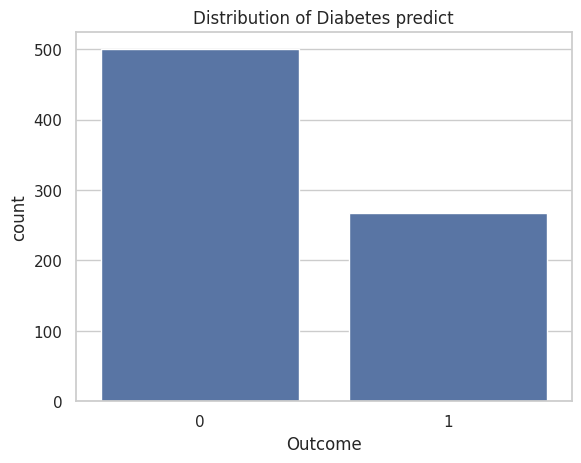

In [20]:
sns.countplot(data = df, x = "Outcome")
plt.title("Distribution of Diabetes predict")
plt.show()

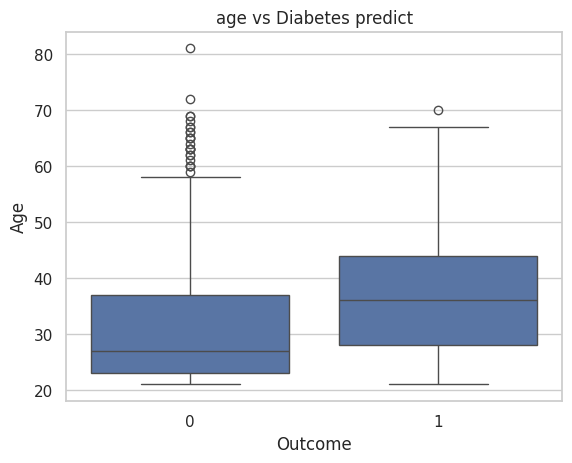

In [19]:
#Bivariate
sns.boxplot(data = df, x = "Outcome", y = "Age")
plt.title("age vs Diabetes predict")
plt.show()

In [18]:
numeric_df = df.select_dtypes(include = ["int64","float64"]).columns

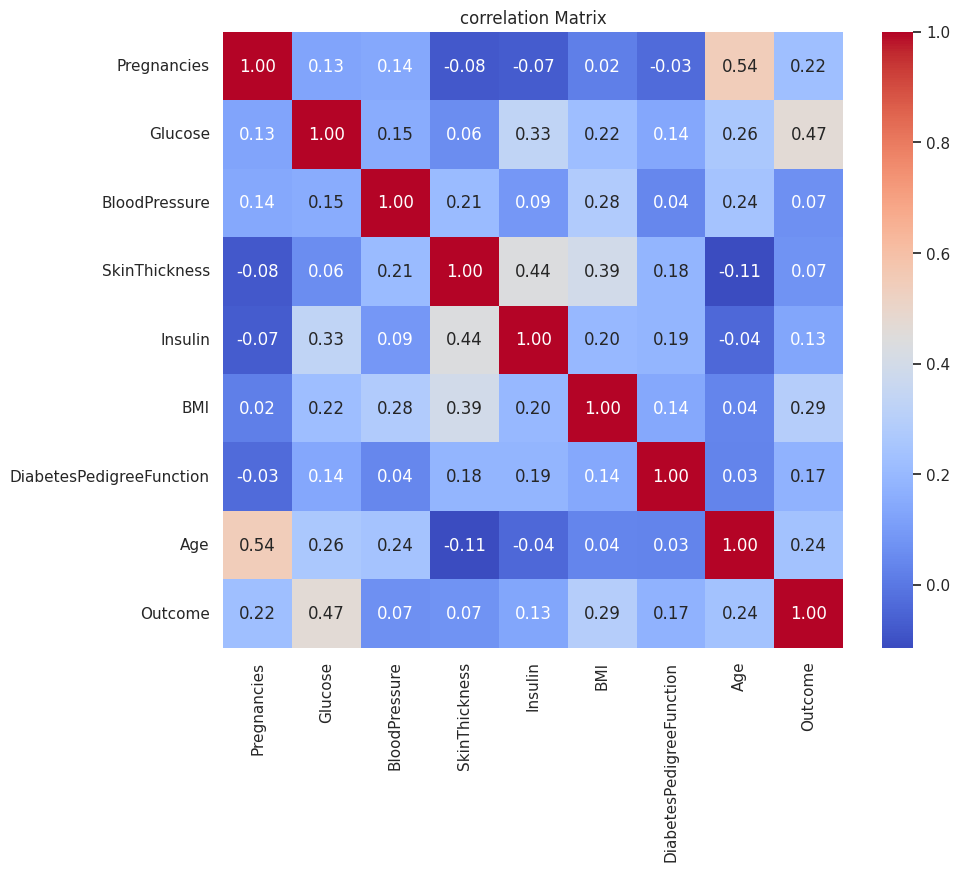

In [21]:
#Multivariate Analysis
plt.figure(figsize = (10, 8))
sns.heatmap(df[numeric_df].corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("correlation Matrix")
plt.show()

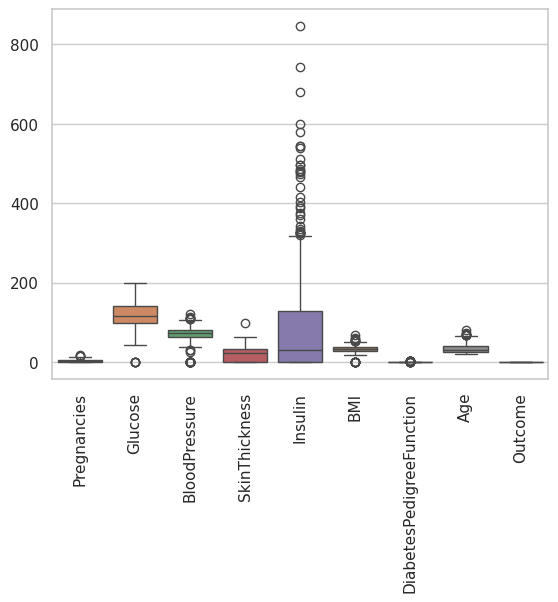

In [22]:
#Outlier detection
sns.boxplot(data = df[numeric_df])
plt.xticks(rotation = 90)
plt.show()

In [23]:
# Treating outliers
outlier_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "IBM",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcomes"
]

In [ ]:
# Apply the IQR
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    # cap values
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

In [25]:
# Correct the column names and re-run IQR outlier capping
outlier_cols = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]


In [26]:
# Apply the IQR
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    # cap values
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

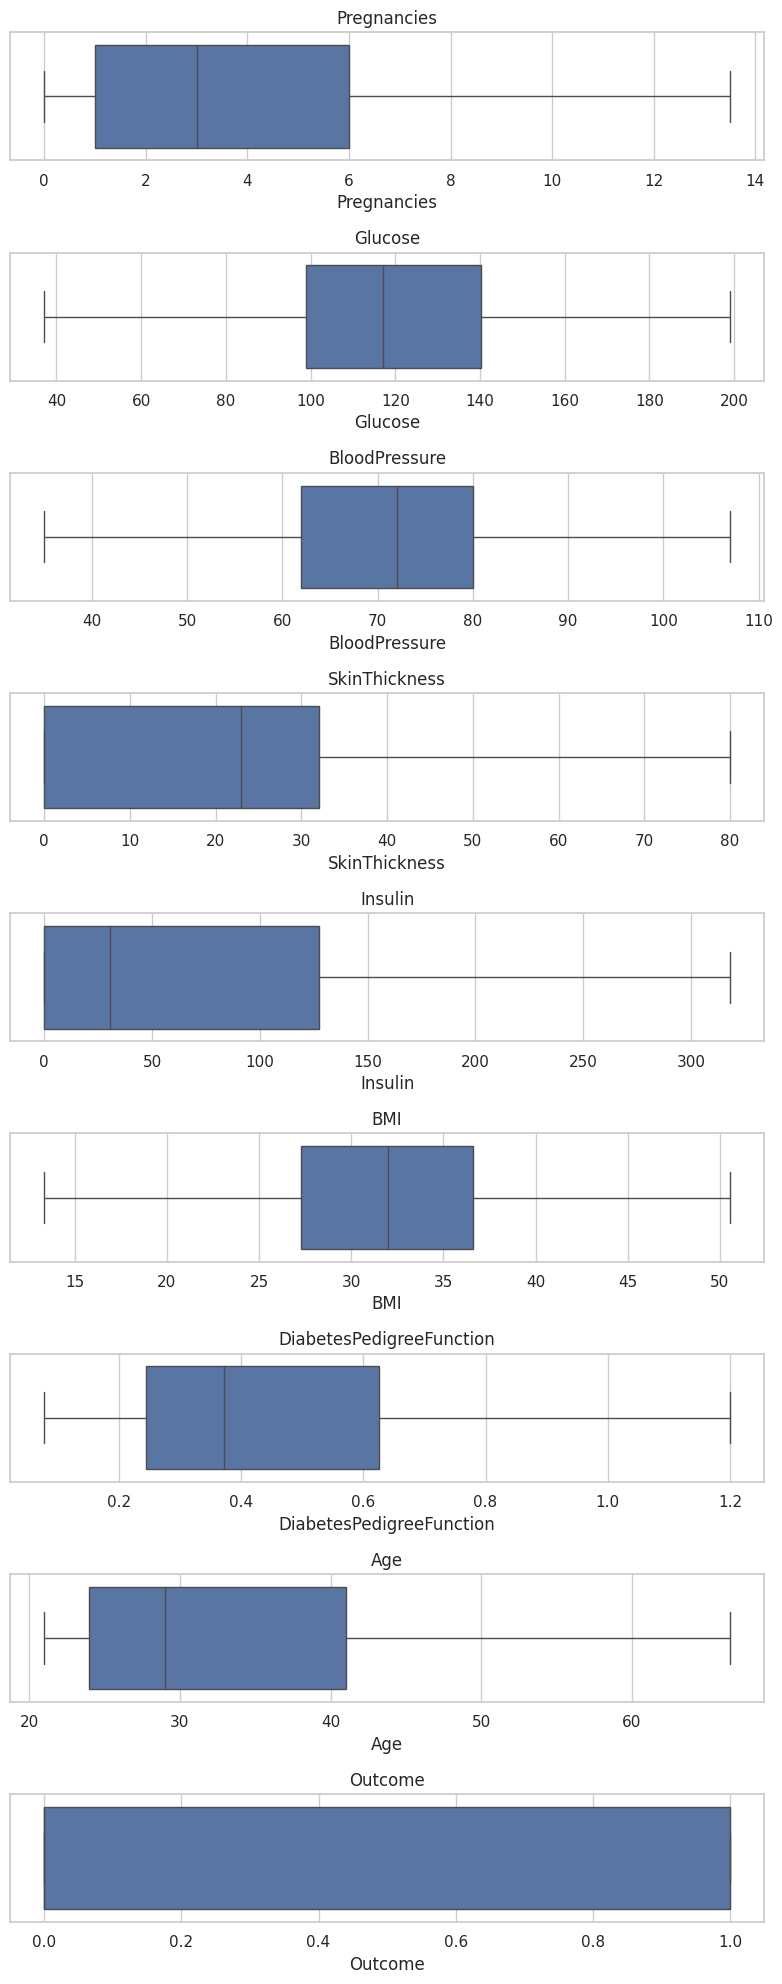

In [27]:
fig, axes = plt.subplots(len(outlier_cols),1, figsize = (8,20))
for i, col in enumerate(outlier_cols):
    sns.boxplot(data = df, x = col, ax = axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [28]:
X =df.drop("Outcome", axis = 1)
y = df["Outcome"]

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [30]:
print(X_train.shape, X_test.shape,y_train.shape, y_test.shape)

(614, 8) (154, 8) (614,) (154,)


In [31]:
from imblearn.over_sampling import SMOTE
print("Before Smote:\n",y_train.value_counts())
smote = SMOTE(random_state = 42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print("After Smote:\n",y_train_resampled.value_counts())

Before Smote:
 Outcome
0.0    401
1.0    213
Name: count, dtype: int64
After Smote:
 Outcome
0.0    401
1.0    401
Name: count, dtype: int64


In [32]:
scaler = StandardScaler()
X_train_resampled = scaler.fit_transform(X_train_resampled)
X_test = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

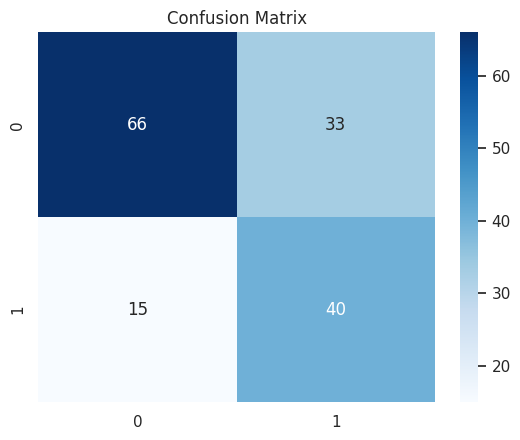

accuracy: 0.6883116883116883
precision: 0.547945205479452
recall: 0.7272727272727273
f1 score: 0.625
classification report:
               precision    recall  f1-score   support

         0.0       0.81      0.67      0.73        99
         1.0       0.55      0.73      0.62        55

    accuracy                           0.69       154
   macro avg       0.68      0.70      0.68       154
weighted avg       0.72      0.69      0.69       154



In [35]:
#Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Generate predictions first
y_pred = model.predict(X_test)

# Calculate metrics using correct target labels
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

sns.heatmap(conf_matrix, annot = True, fmt = "d", cmap = "Blues")
plt.title("Confusion Matrix")
plt.show()

print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1 score:", f1)
print("classification report:\n", class_report)